In [9]:
import numpy as np
import pandas as pd
import time
import FlowCal
from tqdm import tqdm

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import f1_score, normalized_mutual_info_score, adjusted_rand_score, confusion_matrix
from sklearn.manifold import TSNE
from scipy.optimize import linear_sum_assignment
import seaborn as sns
import matplotlib.pyplot as plt


FILENAMES_NO_TRANSFORM = ["FlowRepository_FR-FCM-ZZPH_files/Levine_13dim_notransform.fcs",
                            "FlowRepository_FR-FCM-ZZPH_files/Levine_32dim_notransform.fcs",
                            "FlowRepository_FR-FCM-ZZPH_files/Mosmann_rare_notransform.fcs",
                            "FlowRepository_FR-FCM-ZZPH_files/Nilsson_rare_notransform.fcs",
                            "FlowRepository_FR-FCM-ZZPH_files/Samusik_01_notransform.fcs",
                            "FlowRepository_FR-FCM-ZZPH_files/Samusik_all_notransform.fcs"]
FILENAMES_TRANSFORM = [
    "FlowRepository_FR-FCM-ZZPH_files/Levine_13dim.fcs",
    "FlowRepository_FR-FCM-ZZPH_files/Levine_32dim.fcs",
    "FlowRepository_FR-FCM-ZZPH_files/Mosmann_rare.fcs",
    "FlowRepository_FR-FCM-ZZPH_files/Nilsson_rare.fcs",
    "FlowRepository_FR-FCM-ZZPH_files/Samusik_01.fcs",
    "FlowRepository_FR-FCM-ZZPH_files/Samusik_all.fcs"
]

TEST_CSV_FILE = "../Homework1/Levine_matrix.csv"

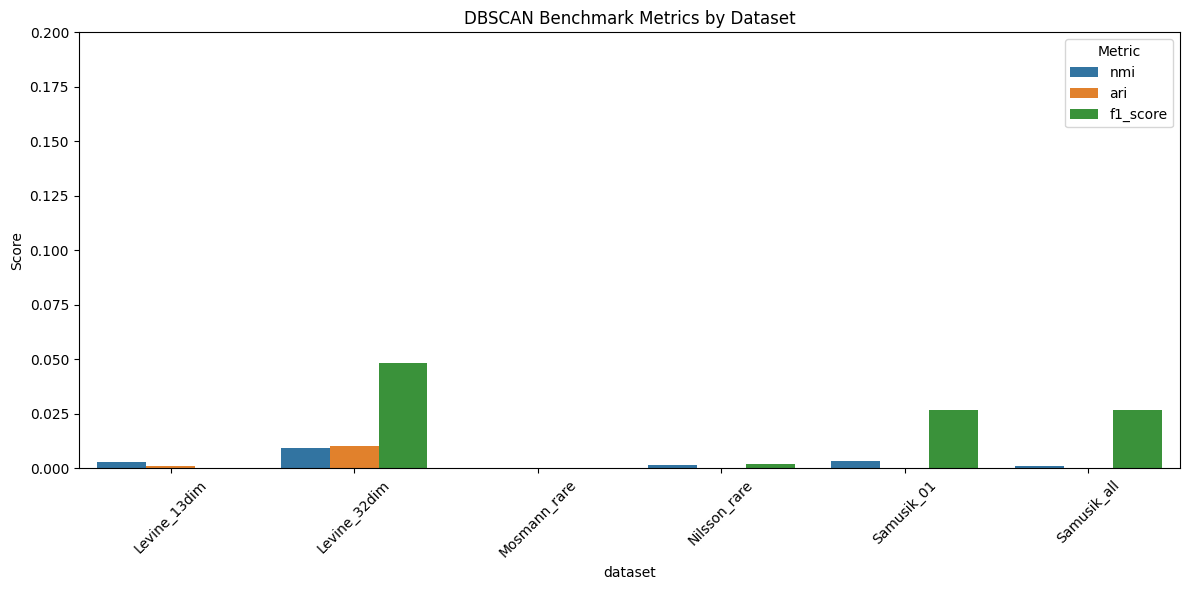

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

combined_csv_path = "benchmark_results_dbscan_auto_full/combined_dbscan_summary.csv"

df = pd.read_csv(combined_csv_path)

melted = df.melt(
    id_vars=["dataset"],
    # removed purity bc it only focuses dominant true label
    value_vars=["nmi", "ari", "f1_score"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=melted, x="dataset", y="Score", hue="Metric")
plt.title("DBSCAN Benchmark Metrics by Dataset")
plt.xticks(rotation=45)
plt.ylim(0, .2)
plt.tight_layout()
plt.legend(title="Metric")
plt.show()


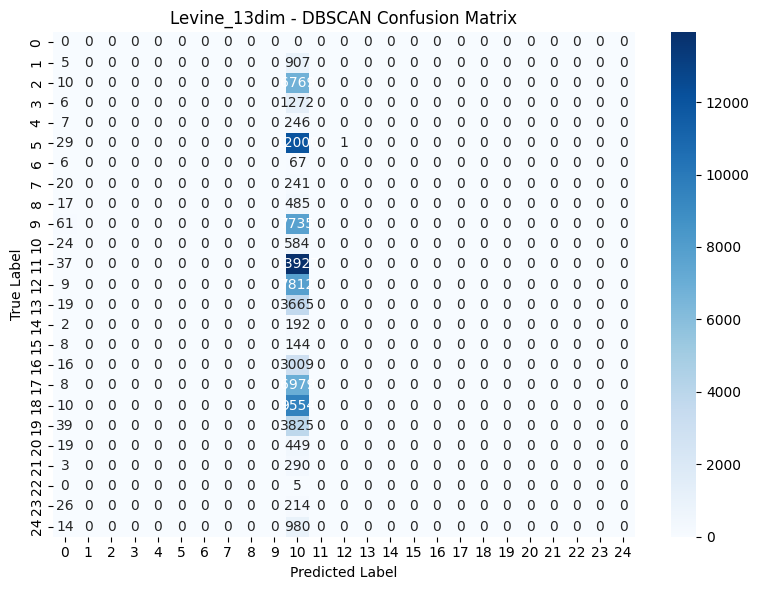

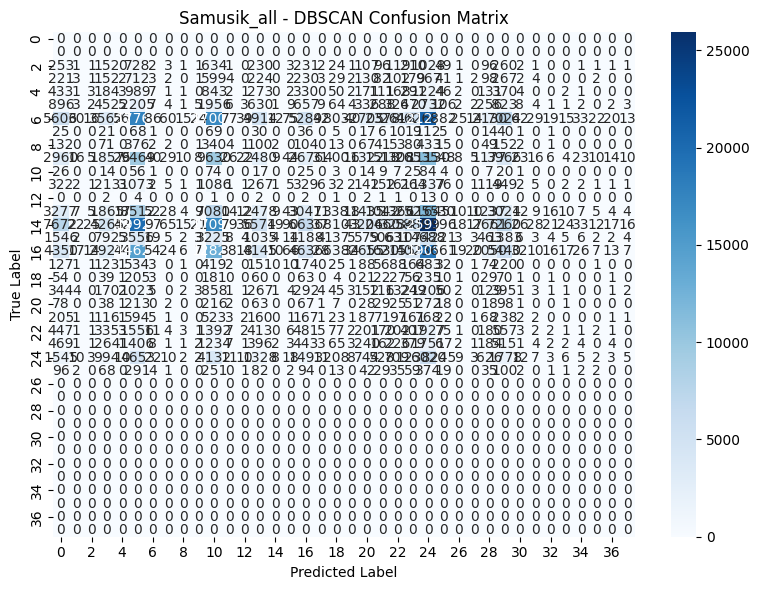

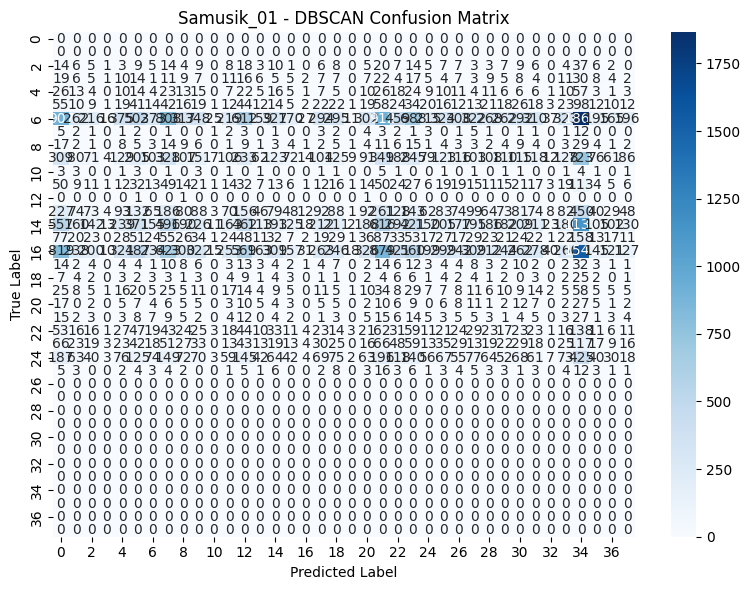

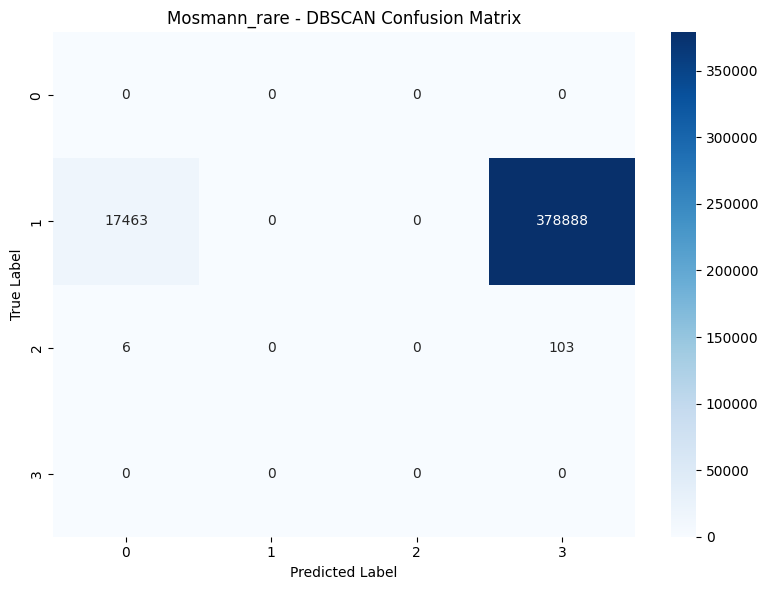

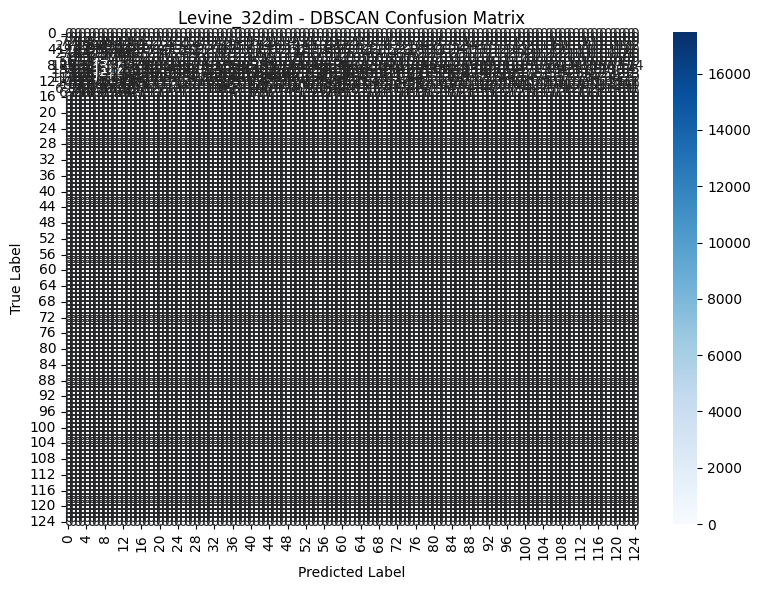

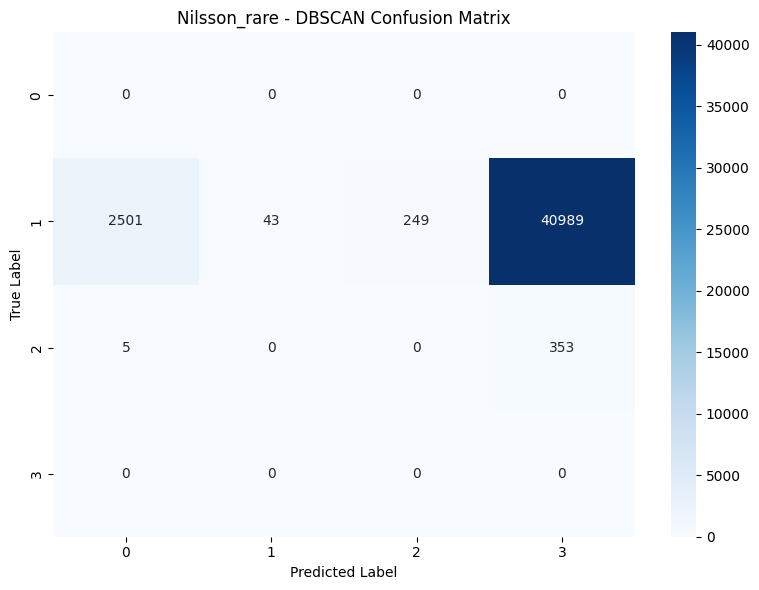

In [11]:
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

benchmark_folder = "benchmark_results_dbscan_auto_full/"

pkl_files = [f for f in os.listdir(benchmark_folder) if f.endswith("_full.pkl")]

for pkl_file in pkl_files:
    full_path = os.path.join(benchmark_folder, pkl_file)
    
    with open(full_path, "rb") as f:
        result = pickle.load(f)
    
    conf_mat = result["confusion_matrix"]
    dataset_name = pkl_file.split("_DBSCAN_")[0]

    # Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{dataset_name} - DBSCAN Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()


        dataset  method      runtime  memory_usage_MB  nmi  ari    purity  \
0  Mosmann_rare  DBSCAN  1315.732459        60.441406  0.0  0.0  0.999725   
1  Levine_32dim  DBSCAN   633.793982        41.187500  0.0  0.0  0.253071   
2  Levine_32dim  DBSCAN   668.160797        42.128906  0.0  0.0  0.253071   
3  Mosmann_rare  DBSCAN   992.885954        53.968750  0.0  0.0  0.999725   
4  Levine_32dim  DBSCAN   649.114911        43.941406  0.0  0.0  0.253071   

   f1_score                                   confusion_matrix  eps  \
0       0.0  [[     0      0      0]\n [396351      0      ...  1.0   
1       0.0  [[    0     0     0     0     0     0     0   ...  2.5   
2       0.0  [[    0     0     0     0     0     0     0   ...  2.0   
3       0.0  [[     0      0      0]\n [396351      0      ...  1.5   
4       0.0  [[    0     0     0     0     0     0     0   ...  1.5   

   min_samples  
0           20  
1           10  
2           20  
3           10  
4            5  


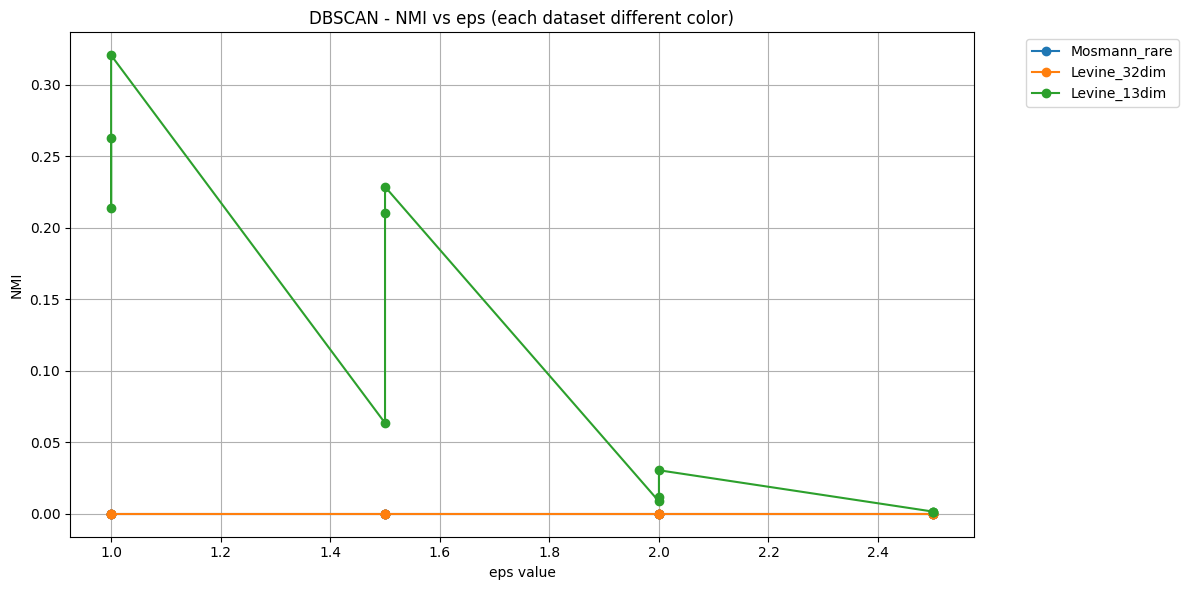

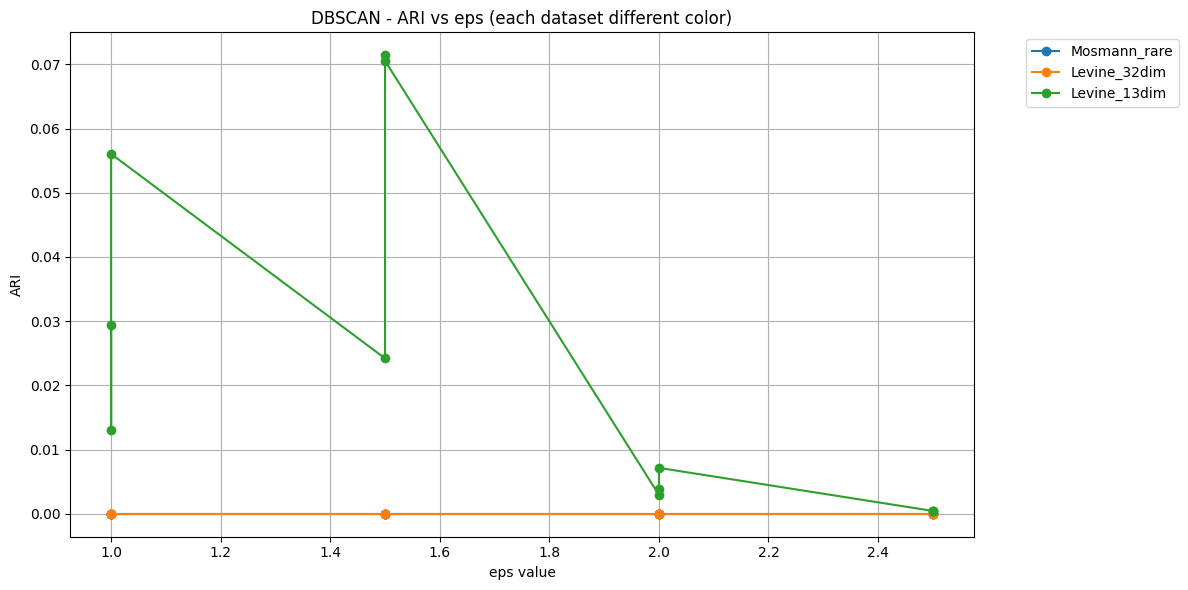

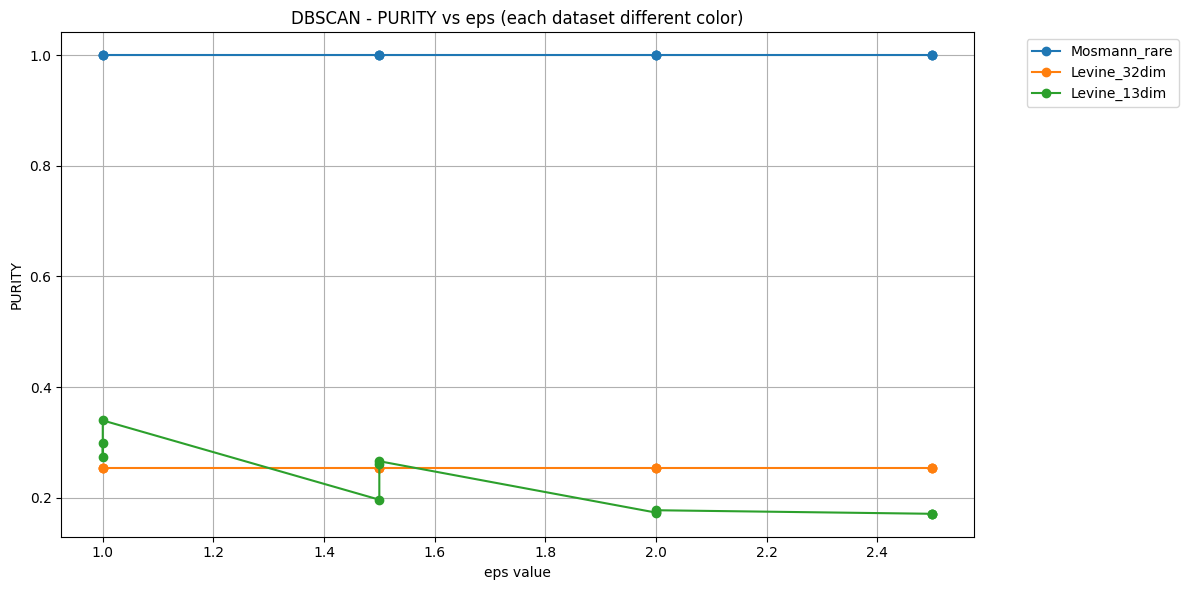

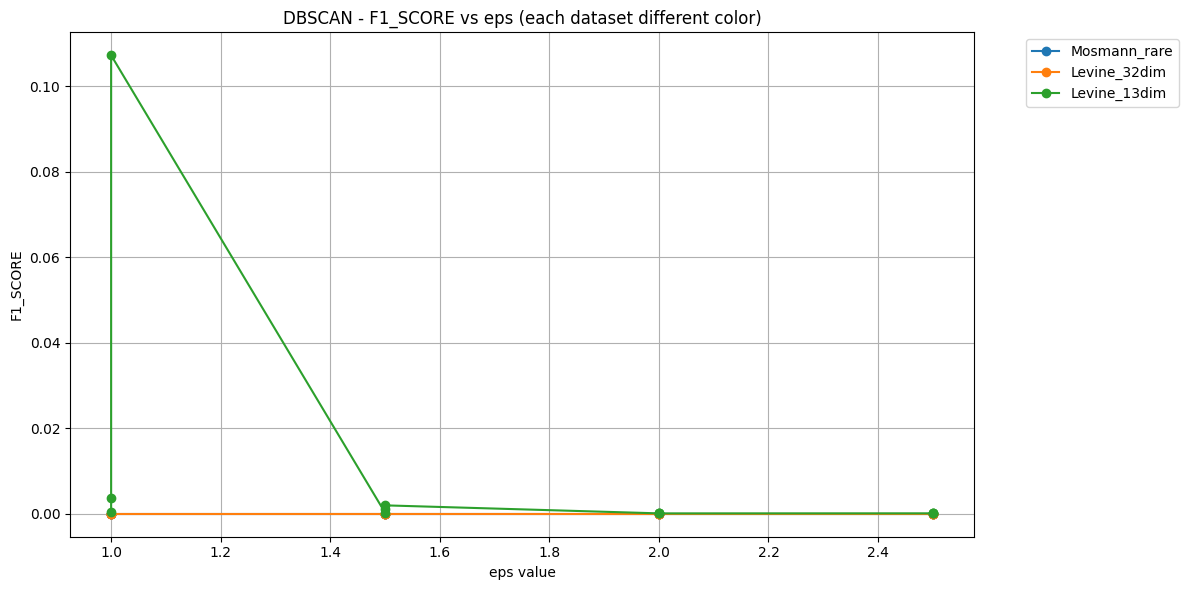

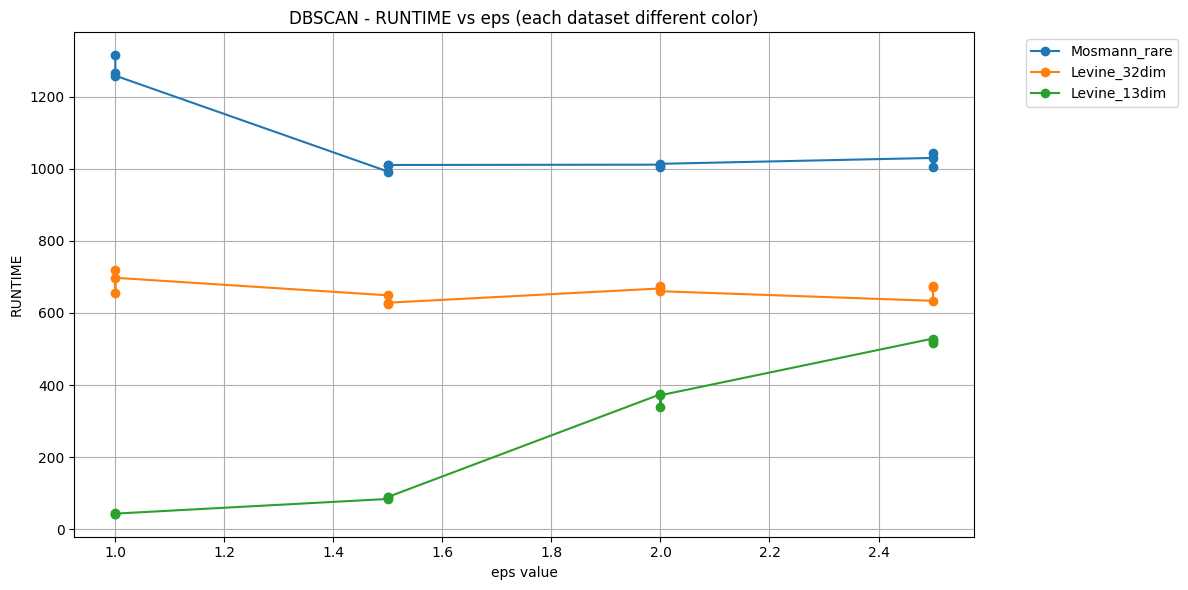

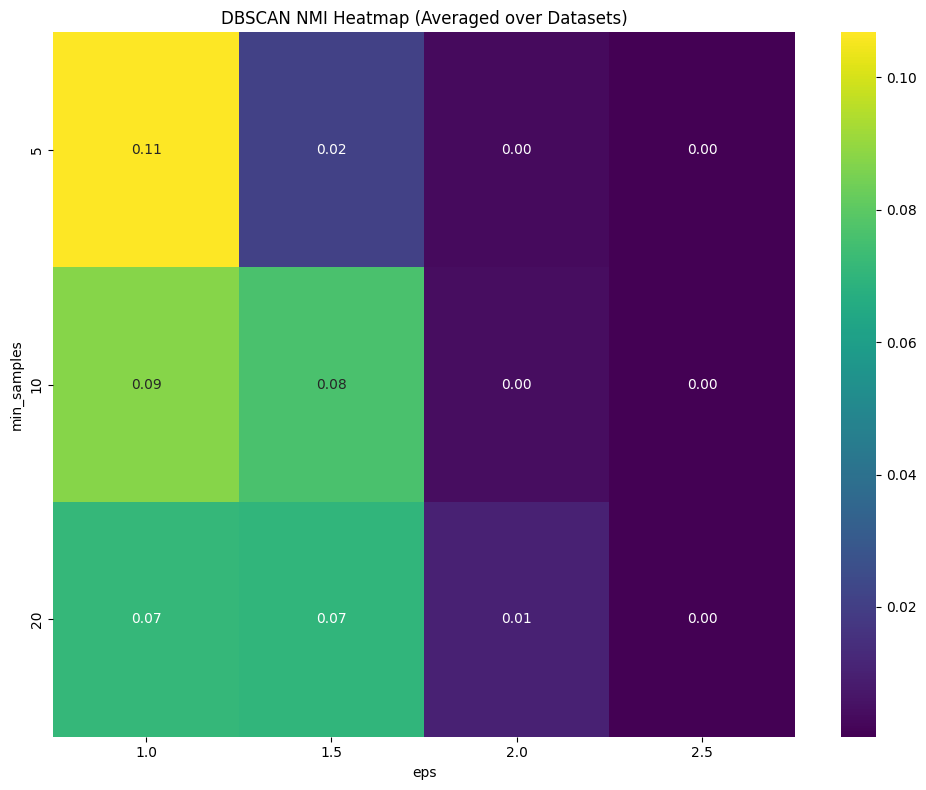

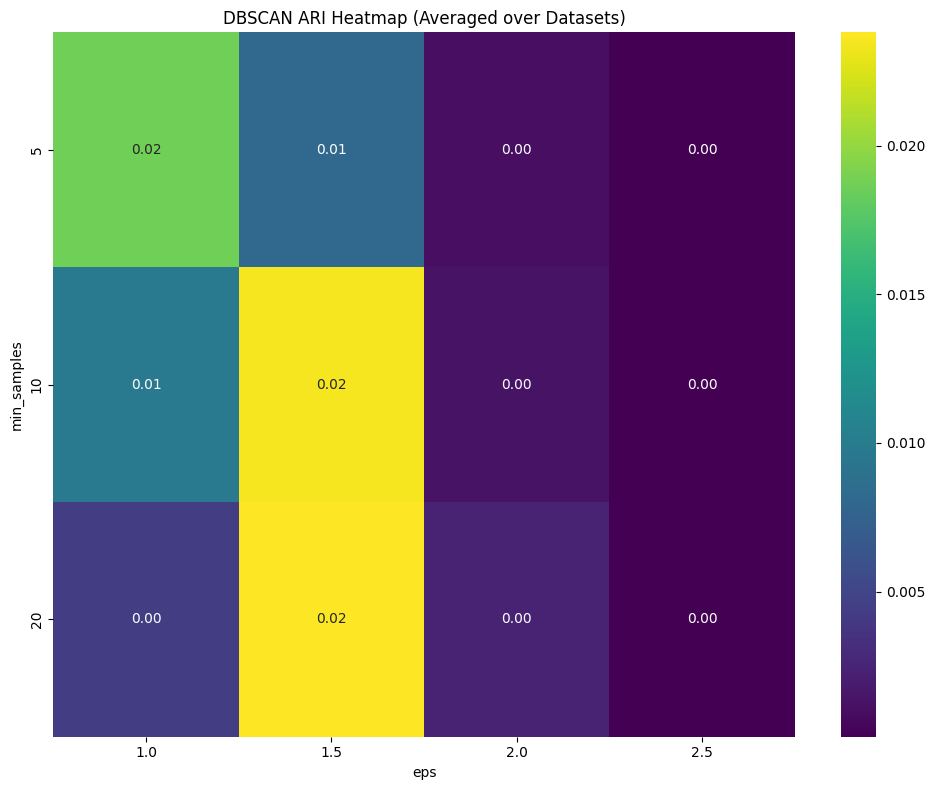

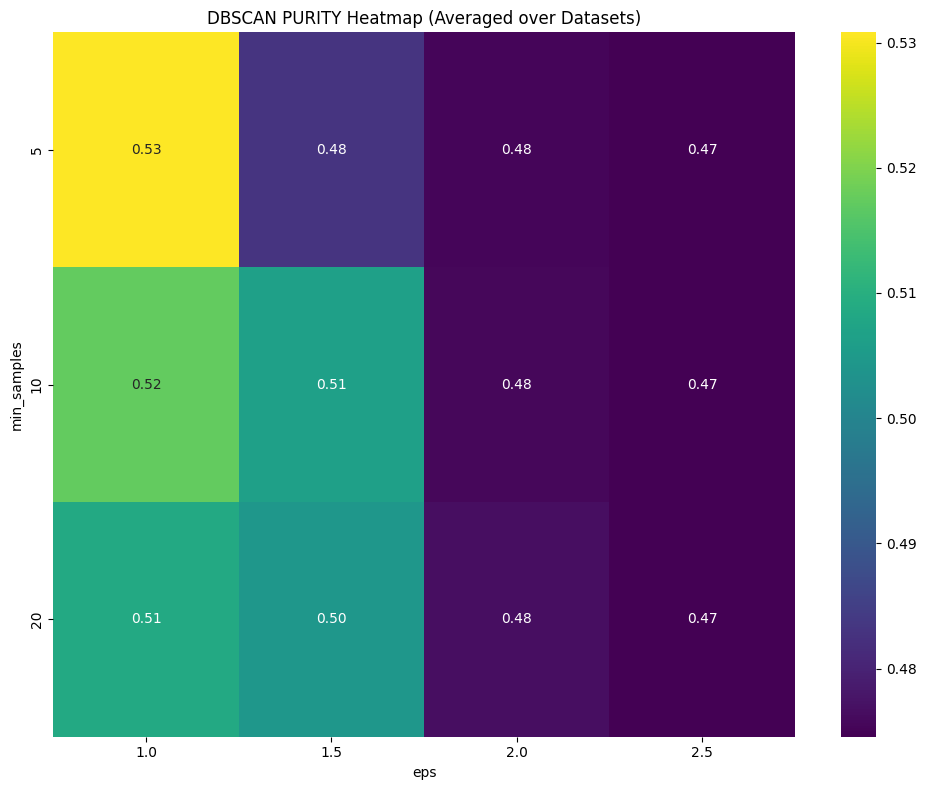

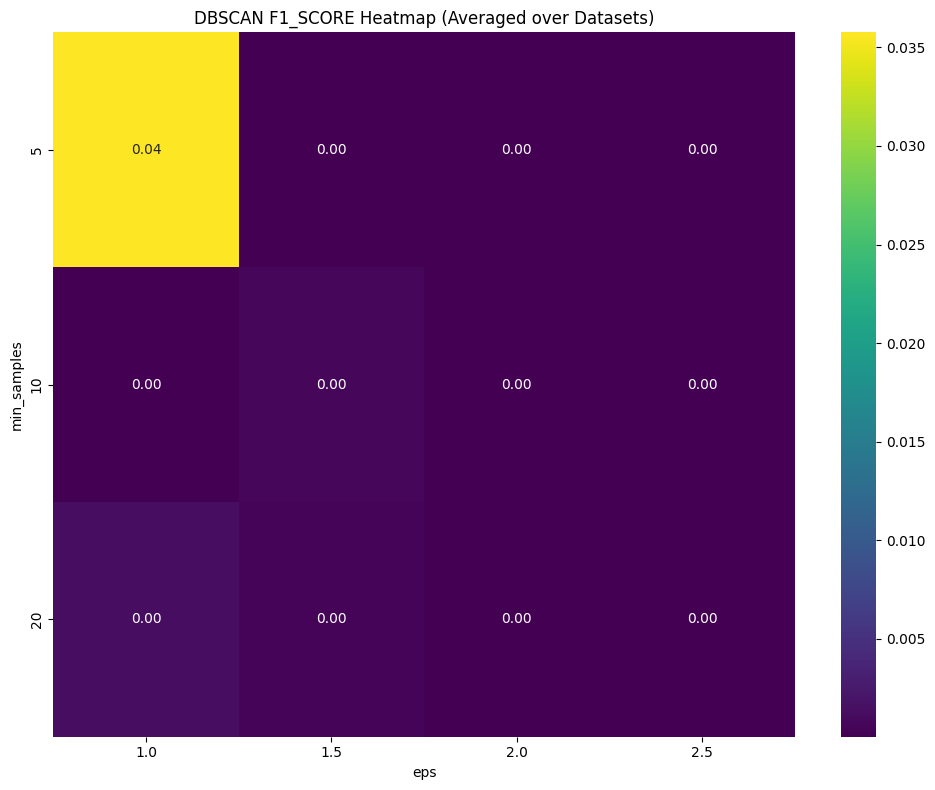

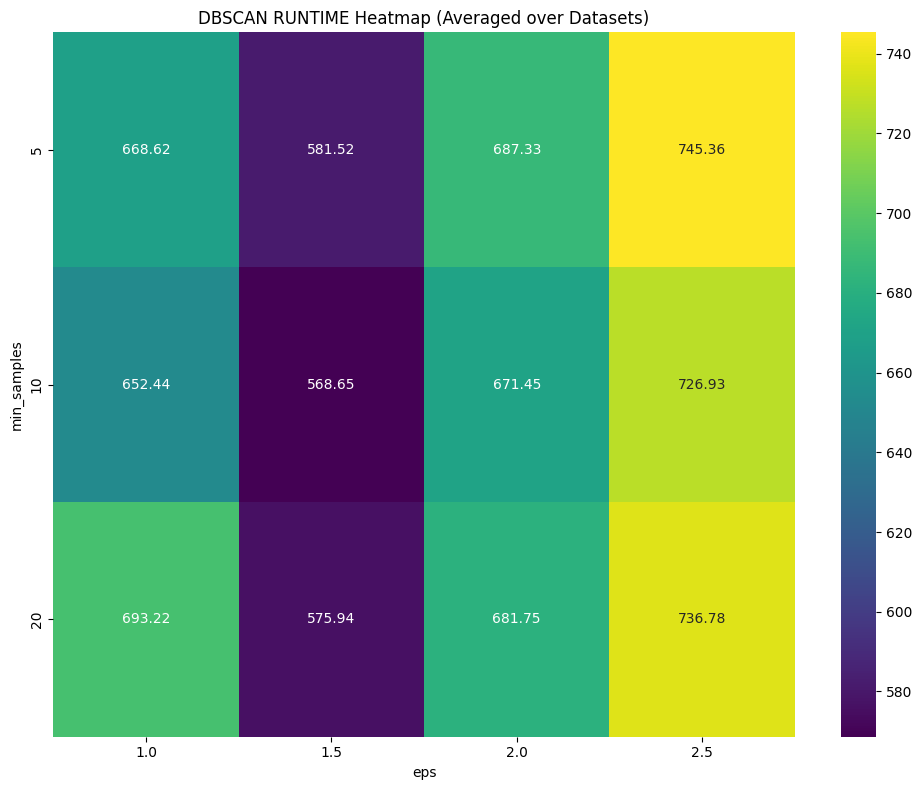

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# varying paramaeters for dbscan

benchmark_folder = "benchmark_results_dbscan/" 
csv_files = glob.glob(os.path.join(benchmark_folder, "*.csv"))

# Combine all results
all_results = []
for file in csv_files:
    df = pd.read_csv(file)
    all_results.append(df)

summary_table = pd.concat(all_results, ignore_index=True)

print(summary_table.head())


metrics = ['nmi', 'ari', 'purity', 'f1_score', 'runtime']

for metric in metrics:
    plt.figure(figsize=(12, 6))
    plt.title(f"DBSCAN - {metric.upper()} vs eps (each dataset different color)")
    
    # Only use transformed datasets first
    transformed_datasets = [d for d in summary_table['dataset'].unique() if "notransform" not in d]

    for dataset in transformed_datasets:
        df_subset = summary_table[summary_table['dataset'] == dataset]

        # Sort by eps so lines make sense
        df_subset = df_subset.sort_values(by='eps')

        plt.plot(df_subset['eps'], df_subset[metric], marker='o', label=dataset)

    plt.xlabel("eps value")
    plt.ylabel(metric.upper())
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# heatmaps

for metric in metrics:
    pivot = summary_table.pivot_table(
        index='min_samples', 
        columns='eps', 
        values=metric,
        aggfunc='mean'
    )

    plt.figure(figsize=(10, 8))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="viridis")
    plt.title(f"DBSCAN {metric.upper()} Heatmap (Averaged over Datasets)")
    plt.xlabel("eps")
    plt.ylabel("min_samples")
    plt.tight_layout()
    plt.show()
